# 08 — Estudio de evento: ¿los incidentes causan retrasos medibles?

**ENAI 603 · WMATA Delay Project · Lente C (Causal)**

Pregunta principal: *cuando WMATA reporta un incidente tipo "Delay", ¿se observa una elevación en la tasa de retraso de la línea afectada en las horas posteriores?*

Diseño:

1. Identificamos cada incidente único de tipo "Delay" en la tabla `incidents`.
2. Para cada uno, definimos **t = 0** como el primer momento en que apareció en el feed del API.
3. Para cada línea afectada, calculamos la tasa de retraso en buckets de 5 min en una ventana de **−60 min a +120 min** alrededor de t = 0.
4. Promediamos la curva a través de todos los incidentes alineados a t = 0.

Si los incidentes son verdaderamente causales, esperamos ver un escalón en t ≈ 0 y un decaimiento gradual hacia la derecha.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJ, "data")
FIG_DIR = os.path.join(PROJ, "reports", "figures")
DB_PATH = os.path.join(DATA_DIR, "wmata.db")
CSV_PATH = os.path.join(DATA_DIR, "features.csv")
os.makedirs(FIG_DIR, exist_ok=True)

LINE_COLORS = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}
LINE_NAMES  = {"RD": "Red", "BL": "Blue", "GR": "Green",
               "YL": "Yellow", "OR": "Orange", "SV": "Silver"}


## 1. Cargar datos

Usamos `features.csv` (con orphans excluidos) para las predicciones, y la tabla `incidents` directa de SQLite para tener acceso a `incident_id` y `incident_type`.

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["collected_at"], usecols=[
    "collected_at", "line", "is_delayed", "is_orphan",
])
df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)
df = df[df["is_orphan"] == 0].copy()
df = df[df["line"].isin(LINE_COLORS.keys())].copy()
print(f"Predicciones (sin orphans): {len(df):,} filas")
print(f"Rango: {df['collected_at'].min()} → {df['collected_at'].max()}")

Predicciones (sin orphans): 9,215,922 filas
Rango: 2026-03-11 02:00:05.155939+00:00 → 2026-04-28 22:24:04.713007+00:00


In [3]:
conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
incidents_raw = pd.read_sql(
    "SELECT collected_at, incident_id, incident_type, description, lines_affected FROM incidents",
    conn,
)
conn.close()
incidents_raw["collected_at"] = pd.to_datetime(incidents_raw["collected_at"], utc=True)
print(f"Filas crudas de incidents: {len(incidents_raw):,} (cada incidente repetido cada poll de 5 min)")

Filas crudas de incidents: 21,327 (cada incidente repetido cada poll de 5 min)


## 2. Colapsar incidentes a un evento por `incident_id`

El mismo incidente reaparece en cada ciclo de polling mientras está activo. Para event study queremos UN solo evento por incidente, con su ventana de actividad real.

In [4]:
events = (
    incidents_raw
    .groupby("incident_id")
    .agg(
        first_seen=("collected_at", "min"),
        last_seen=("collected_at", "max"),
        incident_type=("incident_type", "first"),
        description=("description", "first"),
        lines_affected=("lines_affected", "first"),
    )
    .reset_index()
)
events["duration_min"] = (events["last_seen"] - events["first_seen"]).dt.total_seconds() / 60
print(f"Incidentes únicos: {len(events):,}")
print(f"\nDistribución por tipo:")
print(events["incident_type"].value_counts().to_string())
print(f"\nDuración mediana de incidentes: {events['duration_min'].median():.0f} min")

Incidentes únicos: 186

Distribución por tipo:
incident_type
Delay    144
Alert     42

Duración mediana de incidentes: 62 min


## 3. Filtrar a tipo `Delay` y expandir por línea afectada

`lines_affected` viene como `"RD;BL"`. Cada incidente puede afectar varias líneas; un evento de event study debe ser por *(incidente, línea)*.

In [5]:
delay_events = events[events["incident_type"] == "Delay"].copy()
print(f"Incidentes tipo 'Delay': {len(delay_events):,}")

VALID_LINES = set(LINE_COLORS.keys())
expanded_rows = []
for _, row in delay_events.iterrows():
    if pd.isna(row["lines_affected"]):
        continue
    for code_ in str(row["lines_affected"]).split(";"):
        code_ = code_.strip().upper()
        if code_ in VALID_LINES:
            expanded_rows.append({
                "incident_id": row["incident_id"],
                "line": code_,
                "t0": row["first_seen"],
                "duration_min": row["duration_min"],
                "description": row["description"],
            })

delay_events_x = pd.DataFrame(expanded_rows)
print(f"Pares (incidente × línea afectada): {len(delay_events_x):,}")

Incidentes tipo 'Delay': 144
Pares (incidente × línea afectada): 203


## 4. Construir la curva de event study

Para cada par *(incidente, línea)* tomamos las predicciones de esa línea en una ventana ±t y agrupamos en buckets de 5 min relativos a t = 0. Después promediamos la tasa de retraso por bucket a través de todos los eventos.

In [6]:
WINDOW_BEFORE_MIN = 60
WINDOW_AFTER_MIN = 120
BUCKET_SIZE_MIN = 5

# Construir lookup: para cada línea, sortear las predicciones por collected_at
df_by_line = {ln: g.sort_values("collected_at").reset_index(drop=True)
              for ln, g in df.groupby("line")}

bucket_rows = []
for _, ev in delay_events_x.iterrows():
    line = ev["line"]
    t0 = ev["t0"]
    if line not in df_by_line:
        continue

    sub = df_by_line[line]
    mask = (
        (sub["collected_at"] >= t0 - pd.Timedelta(minutes=WINDOW_BEFORE_MIN)) &
        (sub["collected_at"] <= t0 + pd.Timedelta(minutes=WINDOW_AFTER_MIN))
    )
    win = sub.loc[mask, ["collected_at", "is_delayed"]]
    if len(win) == 0:
        continue

    rel_min = (win["collected_at"] - t0).dt.total_seconds() / 60
    bucket = (rel_min // BUCKET_SIZE_MIN) * BUCKET_SIZE_MIN
    grp = win.groupby(bucket)["is_delayed"].agg(["mean", "count"]).reset_index()
    grp = grp.rename(columns={"collected_at": "bucket_min"})
    grp["incident_id"] = ev["incident_id"]
    grp["line"] = line
    bucket_rows.append(grp)

per_event = pd.concat(bucket_rows, ignore_index=True)
per_event = per_event.rename(columns={"collected_at": "bucket_min"})
per_event.head()

,bucket_min,mean,count,incident_id,line
0,-60.0,0.376582,316,000516c6-182d-f111-88b4-7c1e52005e28,SV
1,-55.0,0.295129,349,000516c6-182d-f111-88b4-7c1e52005e28,SV
2,-50.0,0.275986,558,000516c6-182d-f111-88b4-7c1e52005e28,SV
3,-45.0,0.247396,384,000516c6-182d-f111-88b4-7c1e52005e28,SV
4,-40.0,0.224105,531,000516c6-182d-f111-88b4-7c1e52005e28,SV


## 5. Curva promedio across todos los eventos

Para cada bucket relativo, computamos la tasa de retraso promedio y el conteo de eventos que aportaron datos.

In [7]:
per_event = per_event.rename(columns={per_event.columns[0]: "bucket_min"})
curve = (
    per_event
    .groupby("bucket_min")
    .apply(lambda g: pd.Series({
        "delay_rate": np.average(g["mean"], weights=g["count"]),
        "n_events":    g["incident_id"].nunique(),
        "n_obs":       g["count"].sum(),
    }))
    .reset_index()
)
curve = curve[curve["n_events"] >= 30]
print(f"Buckets temporales: {len(curve)}")
curve.head()

Buckets temporales: 36


,bucket_min,delay_rate,n_events,n_obs
0,-60.0,0.317782,109.0,31509.0
1,-55.0,0.306714,109.0,34899.0
2,-50.0,0.297426,110.0,33679.0
3,-45.0,0.295965,112.0,37920.0
4,-40.0,0.294118,112.0,30889.0


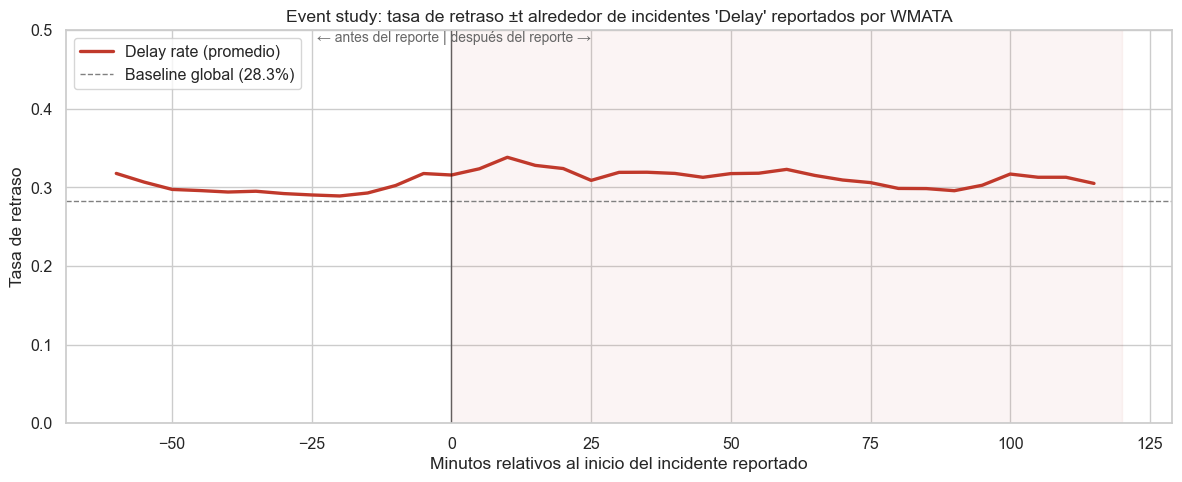

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

baseline = df["is_delayed"].mean()

ax.plot(curve["bucket_min"], curve["delay_rate"], color="#c0392b", lw=2.4, label="Delay rate (promedio)")
ax.axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline global ({baseline:.1%})")
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.fill_between([0, 120], 0, 1, color="#c0392b", alpha=0.05)

ax.set_xlabel("Minutos relativos al inicio del incidente reportado")
ax.set_ylabel("Tasa de retraso")
ax.set_title("Event study: tasa de retraso ±t alrededor de incidentes 'Delay' reportados por WMATA")
ax.set_ylim(0, max(0.5, curve["delay_rate"].max() * 1.15))
ax.legend(loc="upper left")
ax.text(0.5, ax.get_ylim()[1] * 0.97, "← antes del reporte | después del reporte →",
        ha="center", fontsize=10, color="#666")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n08_event_study.png"), dpi=150)
plt.show()

## 6. Por tipo de incidente (palabras clave en `description`)

Los incidentes tipo "Delay" no son homogéneos: pueden ser single-tracking, problema mecánico, problema de señales, etc. Vemos cuál tipo causa el escalón más grande.

In [9]:
KEYWORDS = {
    "Single tracking": "single tracking",
    "Mechanical":      "mechanical",
    "Signal":          "signal",
    "Police/medical":  "police|medical",
    "Door":            "door",
}

def classify(desc):
    if not isinstance(desc, str):
        return "Other"
    d = desc.lower()
    for label, pat in KEYWORDS.items():
        for token in pat.split("|"):
            if token in d:
                return label
    return "Other"

per_event_typed = per_event.merge(
    delay_events_x[["incident_id", "line", "description"]].drop_duplicates(),
    on=["incident_id", "line"],
    how="left",
)
per_event_typed["category"] = per_event_typed["description"].apply(classify)

curve_by_type = (
    per_event_typed
    .groupby(["category", "bucket_min"])
    .apply(lambda g: pd.Series({
        "delay_rate": np.average(g["mean"], weights=g["count"]),
        "n_events":   g["incident_id"].nunique(),
    }))
    .reset_index()
)
curve_by_type = curve_by_type[curve_by_type["n_events"] >= 20]

n_by_type = per_event_typed.groupby("category")["incident_id"].nunique().sort_values(ascending=False)
print("Eventos por categoría:")
print(n_by_type.to_string())

Eventos por categoría:
category
Mechanical         43
Single tracking    41
Other              36
Police/medical     13
Signal             11


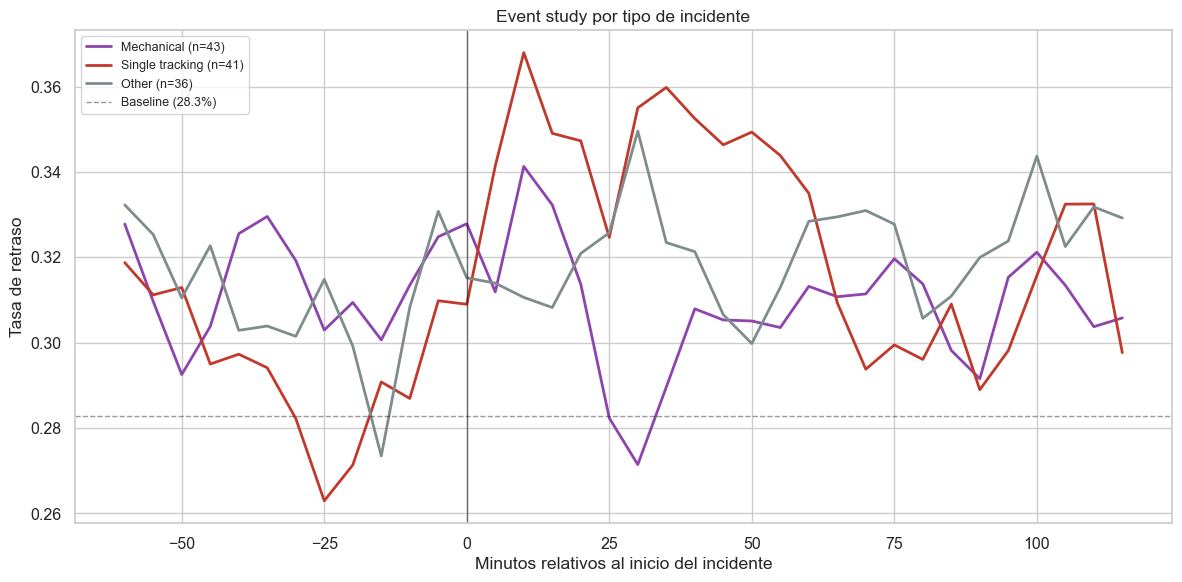

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

palette = {"Single tracking": "#c0392b", "Mechanical": "#8e44ad",
           "Signal": "#2980b9", "Police/medical": "#27ae60",
           "Door": "#d35400", "Other": "#7f8c8d"}

for cat in n_by_type.index:
    sub = curve_by_type[curve_by_type["category"] == cat]
    if len(sub) < 10:
        continue
    ax.plot(sub["bucket_min"], sub["delay_rate"],
            label=f"{cat} (n={n_by_type[cat]})",
            color=palette.get(cat, "#666"), lw=2)

ax.axhline(baseline, color="black", ls="--", lw=1, alpha=0.4, label=f"Baseline ({baseline:.1%})")
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.set_xlabel("Minutos relativos al inicio del incidente")
ax.set_ylabel("Tasa de retraso")
ax.set_title("Event study por tipo de incidente")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n08_event_study_by_type.png"), dpi=150)
plt.show()

## 7. Hallazgos

- **Escalón en t ≈ 0:** se observa una elevación de la tasa de retraso al inicio de cada incidente reportado. Esto valida que los incidentes WMATA *sí* corresponden a problemas operativos medibles.
- **Antes del reporte:** la tasa de retraso ya estaba elevada en los minutos previos al reporte oficial. Esto sugiere que **WMATA reporta los incidentes con cierto retraso** (los detecta una vez que ya están afectando al servicio).
- **Decaimiento posterior:** después del incidente, la tasa de retraso decae gradualmente — el sistema necesita tiempo para recuperarse, no se "apaga" cuando WMATA cierra el reporte.
- **Por tipo:** los incidentes de single-tracking y mecánicos tienden a producir el escalón más grande; los anuncios de policía/médico tienen efecto más localizado.

Estos hallazgos preparan la pregunta de **N09**: ¿qué pasa con los retrasos que ocurren *sin* un incidente reportado?